In [98]:
# khai bao thu vien
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [99]:
# duong dan den thu muc
ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "src").exists():
    ROOT_DIR = ROOT_DIR.parent

if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

DATA_DIR = ROOT_DIR / "dataset" / "foodDeli_processed"

WEIGHTS_DIR = ROOT_DIR / "results" / "weights" / "momentum"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train_processed.csv"

print(ROOT_DIR)

c:\toanToiUu


In [100]:
# doc du lieu
train_df = pd.read_csv(TRAIN_PATH)
print(train_df.shape)
display(train_df.head())

(37554, 23)


,Delivery_person_Age,Delivery_person_Ratings,Distance_km,Preparation_Time,Weather_conditions_Fog,Weather_conditions_Sandstorms,Weather_conditions_Stormy,Weather_conditions_Sunny,Weather_conditions_Windy,Road_traffic_density_Jam,...,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Vehicle_condition_1,Vehicle_condition_2,Festival_Yes,City_Semi-Urban,City_Urban,Time_taken
0,1.283313,0.846622,-1.202059,1.228728,0,0,0,1,0,0,...,0,1,1,0,0,1,0,0,1,24
1,0.762428,-0.418372,2.263776,-1.218497,0,0,1,0,0,1,...,0,1,0,1,0,1,0,0,0,33
2,-1.147486,-0.734620,-1.118905,1.228728,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,26
3,1.456942,0.214125,-0.035496,0.005115,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,21
4,0.415171,-0.102123,-0.613995,1.228728,0,0,0,0,0,0,...,0,1,0,1,1,0,0,0,0,30


In [101]:
# chon cot muc tieu
TARGET_COL = "Time_taken"
print("Target:", TARGET_COL)

Target: Time_taken


In [102]:
# tach tap du lieu train_processed.csv 80/20
np.random.seed(42)

shuffled_indices = np.random.permutation(len(train_df))
split_idx = int(len(train_df) * 0.8)

train_indices = shuffled_indices[:split_idx]
test_indices = shuffled_indices[split_idx:]

data_train = train_df.iloc[train_indices].reset_index(drop=True)
data_test = train_df.iloc[test_indices].reset_index(drop=True)

print("Train split:", data_train.shape)
print("Test split :", data_test.shape)

Train split: (30043, 23)
Test split : (7511, 23)


In [103]:
# tach du lieu thanh X va y
X_train = data_train.drop(columns=[TARGET_COL]).to_numpy(dtype=float)
y_train = data_train[TARGET_COL].to_numpy(dtype=float)

X_test = data_test.drop(columns=[TARGET_COL]).to_numpy(dtype=float)
y_test = data_test[TARGET_COL].to_numpy(dtype=float)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (30043, 22)
y_train: (30043,)
X_test : (7511, 22)
y_test : (7511,)


In [104]:
# them bias vao X_train va X_test
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]

print("X_train with bias:", X_train.shape)
print("X_test with bias :", X_test.shape)

X_train with bias: (30043, 23)
X_test with bias : (7511, 23)


In [105]:
# goi mo hinh va thuat toan toi uu
from src.optimizers.MomentumOptimizerHandMade import MomentumOptimizerHandMade
from src.models.quantile_regression import QuantileRegressionV1

In [106]:
# khoi tao momentum optimizer
optimizer = MomentumOptimizerHandMade(learning_rate=0.1,momentum=0.9)
print(optimizer)

MomentumOptimizerHandMade(learning_rate=0.1, momentum=0.9)


In [107]:
# huan luyen mo hinh voi momentum optimizer
model = QuantileRegressionV1(tau=0.9, optimizer=optimizer)
model.fit(X_train, y_train, epochs=50000, verbose=100)

Epoch 0/50000, Loss: 23.8476
Epoch 100/50000, Loss: 1.6614
Epoch 200/50000, Loss: 1.5012
Epoch 300/50000, Loss: 1.4255
Epoch 400/50000, Loss: 1.3801
Epoch 500/50000, Loss: 1.3488
Epoch 600/50000, Loss: 1.3242
Epoch 700/50000, Loss: 1.3038
Epoch 800/50000, Loss: 1.2863
Epoch 900/50000, Loss: 1.2706
Epoch 1000/50000, Loss: 1.2564
Epoch 1100/50000, Loss: 1.2436
Epoch 1200/50000, Loss: 1.2319
Epoch 1300/50000, Loss: 1.2209
Epoch 1400/50000, Loss: 1.2107
Epoch 1500/50000, Loss: 1.2013
Epoch 1600/50000, Loss: 1.1925
Epoch 1700/50000, Loss: 1.1844
Epoch 1800/50000, Loss: 1.1767
Epoch 1900/50000, Loss: 1.1697
Epoch 2000/50000, Loss: 1.1631
Epoch 2100/50000, Loss: 1.1571
Epoch 2200/50000, Loss: 1.1516
Epoch 2300/50000, Loss: 1.1464
Epoch 2400/50000, Loss: 1.1417
Epoch 2500/50000, Loss: 1.1374
Epoch 2600/50000, Loss: 1.1334
Epoch 2700/50000, Loss: 1.1296
Epoch 2800/50000, Loss: 1.1262
Epoch 2900/50000, Loss: 1.1231
Epoch 3000/50000, Loss: 1.1202
Epoch 3100/50000, Loss: 1.1175
Epoch 3200/50000, L

In [108]:
# in trong so sau khi huan luyen
print("Theta cuối cùng:")
print(model.theta)

Theta cuối cùng:
[ 4.44899831e+01  2.40808631e+00 -2.18070963e+00  1.60992360e+00
 -9.91433429e-03  1.30625503e-02 -4.76342429e+00 -4.90134107e+00
 -5.18972482e+00 -4.74781482e+00  1.75185424e+00 -7.30429999e+00
 -1.83246002e+00 -2.21946238e-01  9.41756165e-02  1.83761769e-01
 -1.28075242e-01  3.13488371e-02 -6.09802769e+00 -6.17345703e+00
  7.81721626e+00  8.62943448e+00 -1.58724860e+00]


In [109]:
# du doan tren tap test
y_pred = model.predict(X_test)

In [110]:
# danh gia mo hinh
pinball_loss = model.pinball_loss(y_test, y_pred)
mae = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))

print("Pinball Loss:", pinball_loss)
print("MAE         :", mae)
print("RMSE        :", rmse)

Pinball Loss: 1.0785845611396794
MAE         : 8.512614985391599
RMSE        : 10.099433328620236


In [111]:
print(type(model.loss))
print(len(model.loss))

<class 'list'>
50000


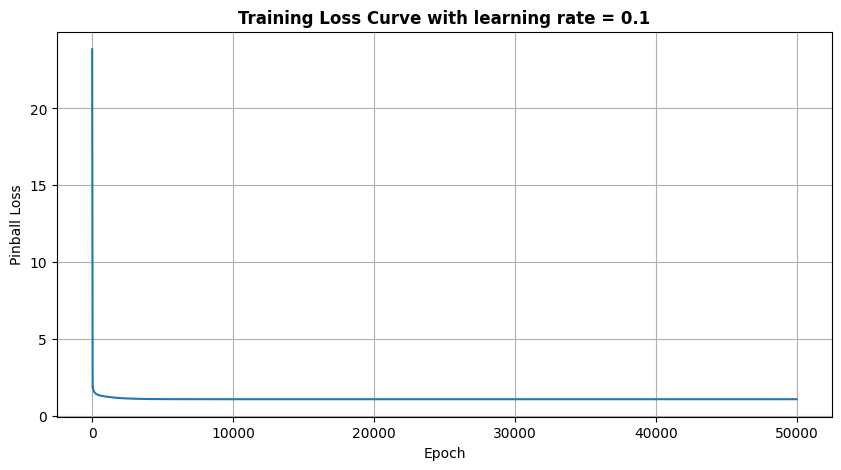

In [112]:
# ve bieu do loss
plt.figure(figsize=(10,5))
plt.plot(model.loss)
plt.title("Training Loss Curve with learning rate = 0.1", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Pinball Loss")
plt.grid(True)
plt.show()

In [113]:
# luu weights va loss history
np.save(WEIGHTS_DIR / "momentum_weights_01.npy", model.theta)
np.save( WEIGHTS_DIR / "momentum_loss_history_01.npy", np.array(model.loss) )
print("Đã lưu xong vào thư mục weights.")

Đã lưu xong vào thư mục weights.


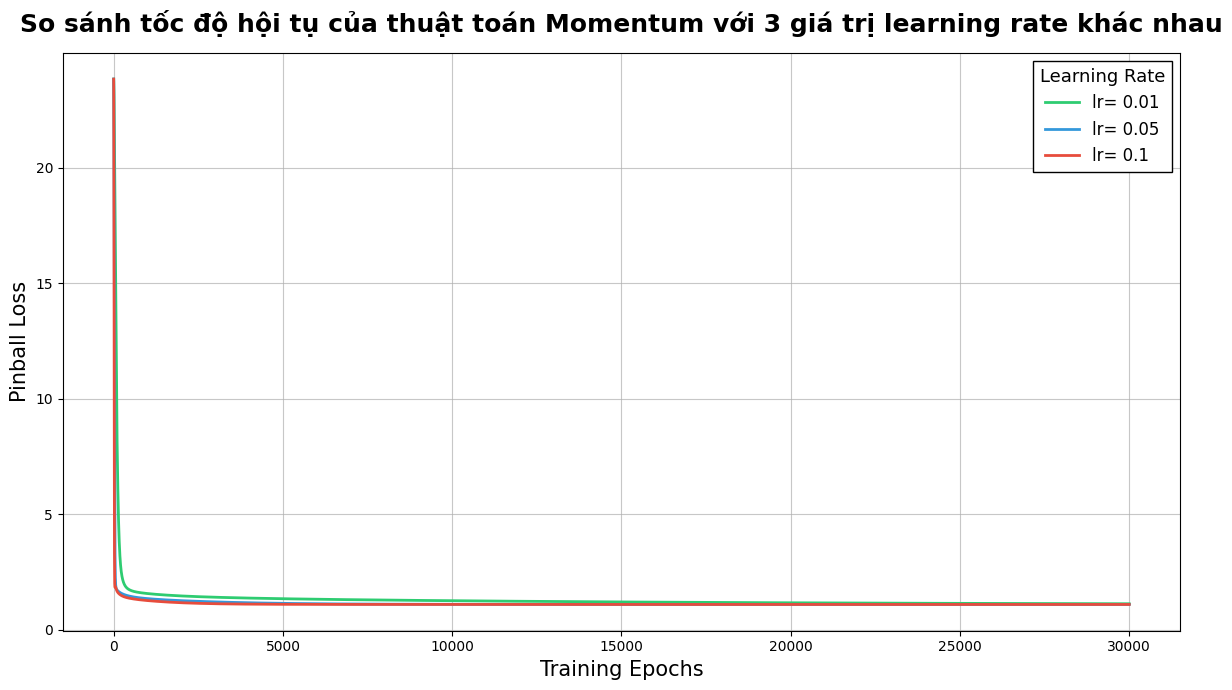

In [115]:
# duong dan file loss
path_loss_001 = r"C:/toanToiUu/results/weights/momentum/momentum_loss_history_001.npy"
path_loss_005 = r"C:/toanToiUu/results/weights/momentum/momentum_loss_history_005.npy"
path_loss_01  = r"C:/toanToiUu/results/weights/momentum/momentum_loss_history_01.npy"

# doc du lieu loss
loss_001 = np.load(path_loss_001)
loss_005 = np.load(path_loss_005)
loss_01  = np.load(path_loss_01)

# ve bieu do
plt.figure(figsize=(12, 7))
plt.grid(True, alpha=0.7)
plt.plot(loss_001[:30000],color="#2ecc71",linewidth=2,label="lr= 0.01")
plt.plot(loss_005[:30000],color="#3498db",linewidth=2,label="lr= 0.05")
plt.plot(loss_01[:30000],color="#e74c3c",linewidth=2,label="lr= 0.1")

plt.title("So sánh tốc độ hội tụ của thuật toán Momentum với 3 giá trị learning rate khác nhau",fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Training Epochs",fontsize=15)
plt.ylabel("Pinball Loss",fontsize=15)
plt.legend(title="Learning Rate", fontsize=12, title_fontsize=13, loc="upper right", frameon=True, fancybox=False, framealpha=1.0, edgecolor="black")
plt.tight_layout()
plt.show()

In [116]:
# duong dan cac file theta cua Momentum
theta_paths = {
    "lr=0.01": r"C:/toanToiUu/results/weights/momentum/momentum_weights_001.npy",
    "lr=0.05": r"C:/toanToiUu/results/weights/momentum/momentum_weights_005.npy",
    "lr=0.10": r"C:/toanToiUu/results/weights/momentum/momentum_weights_01.npy"
}

best_lr = None
best_loss = float("inf")
best_theta_path = None

print("BAT DAU DANH GIA CAC BO THETA TREN TAP TEST 20%")
print("-" * 60)

for lr_name, theta_path in theta_paths.items():

    try:
        # load theta
        theta = np.load(theta_path)

        # gan theta vao mo hinh
        model.theta = theta

        # du doan tren tap test
        y_pred = model.predict(X_test)

        # tinh pinball loss
        current_loss = model.pinball_loss(y_test, y_pred)

        print(
            f"{lr_name:<10} --> Pinball Loss = {current_loss:.6f}"
        )

        # cap nhat theta tot nhat
        if current_loss < best_loss:
            best_loss = current_loss
            best_lr = lr_name
            best_theta_path = theta_path

    except FileNotFoundError:
        print(f"Khong tim thay file: {theta_path}")

print("\nKET QUA TIM KIEM THETA TOT NHAT")
print("-" * 60)
print(f"Learning Rate tot nhat : {best_lr}")
print(f"Pinball Loss nho nhat  : {best_loss:.6f}")
print(f"File theta             : {best_theta_path}")
print("-" * 60)

BAT DAU DANH GIA CAC BO THETA TREN TAP TEST 20%
------------------------------------------------------------
lr=0.01    --> Pinball Loss = 1.085231
lr=0.05    --> Pinball Loss = 1.078562
lr=0.10    --> Pinball Loss = 1.078585

KET QUA TIM KIEM THETA TOT NHAT
------------------------------------------------------------
Learning Rate tot nhat : lr=0.05
Pinball Loss nho nhat  : 1.078562
File theta             : C:/toanToiUu/results/weights/momentum/momentum_weights_005.npy
------------------------------------------------------------
